# Arquitectura, selección y generalización

Objetivo: inspeccionar la única red canónica y sus evidencias sin reentrenar.

In [1]:
from pathlib import Path
import json, pandas as pd
ROOT=Path.cwd()
manifest=json.loads((ROOT/'models/final/manifest.json').read_text())
selection=json.loads((ROOT/'models/final/model_selection.json').read_text())
widths=[manifest['feature_count'],*manifest['architecture']['hidden_units'],1]
params=sum((a+1)*b for a,b in zip(widths,widths[1:]))
{'widths':widths,'trainable_parameters':params,'selection':selection['architecture_selection_partition'],'refit_epochs':selection['fixed_refit_epochs_from_inner_selection']}

{'widths': [169, 64, 32, 1],
 'trainable_parameters': 12993,
 'selection': 'fit_2021_select_2022',
 'refit_epochs': 14}

## Lectura

La arquitectura se selecciona con fit 2021 y selección 2022. El artefacto final se reajusta una vez en 2021-2022 por un número fijo de épocas; 2023 calibra y fija umbrales.

{'schema_version': 1,
 'metric_basis': 'unweighted predictions from the same frozen network',
 'learning_curve_roles': '2021 inner fit vs 2022 inner selection; no 2023 or reference rows',
 'train_pr_auc': 0.43315540962080673,
 'validation_pr_auc': 0.3366581050873884,
 'pr_auc_generalization_gap_train_minus_validation': 0.09649730453341832,
 'train_brier': 0.16432902216911316,
 'validation_brier': 0.16793286800384521,
 'brier_generalization_gap_validation_minus_train': 0.0036038458347320557,
 'weighted_loss_compared_across_partitions': False}

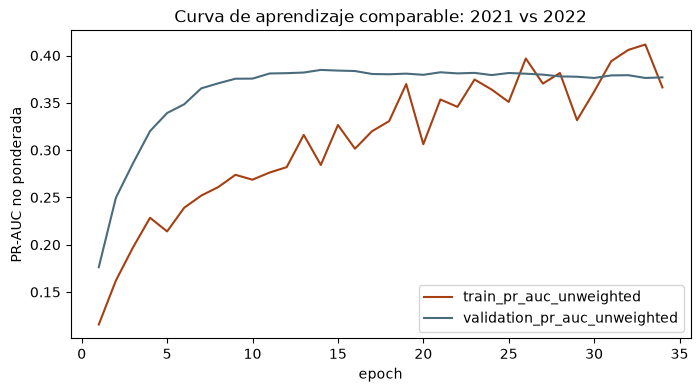

In [2]:
curves=pd.read_csv(ROOT/'report/tables/model_learning_curves.csv')
gap=json.loads((ROOT/'report/tables/model_generalization_gap.json').read_text())
assert {'train_pr_auc_unweighted','validation_pr_auc_unweighted'} <= set(curves)
ax=curves.plot(x='epoch', y=['train_pr_auc_unweighted','validation_pr_auc_unweighted'], figsize=(8,4), color=['#A63F12','#496B7C'])
ax.set_ylabel('PR-AUC no ponderada'); ax.set_title('Curva de aprendizaje comparable: 2021 vs 2022')
gap

## Lectura

Las dos curvas usan la misma métrica no ponderada. No se compara la pérdida de entrenamiento ponderada con una pérdida de validación no ponderada.

### Data Analysis Key Findings
- Se conserva una sola MLP compacta.
- L2, dropout, class weights, early stopping y reducción de LR son técnicas reales y auditables.

### Insights or Next Steps
- Confirmar en una cohorte externa antes de cambiar arquitectura.